In [1]:
import numpy as np 
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
%matplotlib inline


In [2]:
df_tr = pd.read_csv('../data/train.csv', index_col = 'id')

In [41]:
df_tr.info()

<class 'pandas.core.frame.DataFrame'>
Index: 630000 entries, 0 to 629999
Data columns (total 14 columns):
 #   Column                   Non-Null Count   Dtype  
---  ------                   --------------   -----  
 0   Age                      630000 non-null  int64  
 1   Sex                      630000 non-null  int64  
 2   Chest pain type          630000 non-null  int64  
 3   BP                       630000 non-null  int64  
 4   Cholesterol              630000 non-null  int64  
 5   FBS over 120             630000 non-null  int64  
 6   EKG results              630000 non-null  int64  
 7   Max HR                   630000 non-null  int64  
 8   Exercise angina          630000 non-null  int64  
 9   ST depression            630000 non-null  float64
 10  Slope of ST              630000 non-null  int64  
 11  Number of vessels fluro  630000 non-null  int64  
 12  Thallium                 630000 non-null  int64  
 13  Heart Disease            630000 non-null  object 
dtypes: float6

In [42]:
df_tr.sample(10)

,Age,Sex,Chest pain type,BP,Cholesterol,FBS over 120,EKG results,Max HR,Exercise angina,ST depression,Slope of ST,Number of vessels fluro,Thallium,Heart Disease
id,,,,,,,,,,,,,,
54515,66,1,2,150,229,0,2,172,0,0.0,2,0,7,Absence
340009,51,0,4,120,304,0,2,178,1,0.0,1,0,7,Absence
487626,59,0,4,125,226,0,2,155,1,2.4,2,1,7,Presence
462731,58,0,4,120,230,0,0,172,0,0.4,1,0,3,Absence
338293,52,0,3,150,197,0,2,142,0,0.0,1,0,7,Absence
302914,57,1,3,120,204,0,2,130,1,0.8,2,1,7,Presence
278165,59,1,4,112,295,0,2,165,1,1.6,2,2,7,Presence
247196,65,0,3,140,177,0,0,141,0,0.0,2,0,3,Presence
481465,60,1,1,140,288,0,2,179,0,0.0,1,2,7,Presence


In [43]:
for c in df_tr.columns:
    print(c, len(df_tr[c].value_counts()))

Age 42
Sex 2
Chest pain type 4
BP 66
Cholesterol 150
FBS over 120 2
EKG results 3
Max HR 93
Exercise angina 2
ST depression 66
Slope of ST 3
Number of vessels fluro 4
Thallium 3
Heart Disease 2


In [6]:
df_tr.describe()

,id,Age,Sex,Chest pain type,BP,Cholesterol,FBS over 120,EKG results,Max HR,Exercise angina,ST depression,Slope of ST,Number of vessels fluro,Thallium
count,630000.000000,630000.000000,630000.000000,630000.000000,630000.000000,630000.000000,630000.000000,630000.000000,630000.000000,630000.000000,630000.000000,630000.000000,630000.000000,630000.000000
mean,314999.500000,54.136706,0.714735,3.312752,130.497433,245.011814,0.079987,0.981660,152.816763,0.273725,0.716028,1.455871,0.451040,4.618873
std,181865.479132,8.256301,0.451541,0.851615,14.975802,33.681581,0.271274,0.998783,19.112927,0.445870,0.948472,0.545192,0.798549,1.950007
min,0.000000,29.000000,0.000000,1.000000,94.000000,126.000000,0.000000,0.000000,71.000000,0.000000,0.000000,1.000000,0.000000,3.000000
25%,157499.750000,48.000000,0.000000,3.000000,120.000000,223.000000,0.000000,0.000000,142.000000,0.000000,0.000000,1.000000,0.000000,3.000000
50%,314999.500000,54.000000,1.000000,4.000000,130.000000,243.000000,0.000000,0.000000,157.000000,0.000000,0.100000,1.000000,0.000000,3.000000
75%,472499.250000,60.000000,1.000000,4.000000,140.000000,269.000000,0.000000,2.000000,166.000000,1.000000,1.400000,2.000000,1.000000,7.000000
max,629999.000000,77.000000,1.000000,4.000000,200.000000,564.000000,1.000000,2.000000,202.000000,1.000000,6.200000,3.000000,3.000000,7.000000


In [3]:
num_cols = ['Age', 'BP', 'Cholesterol', 'Max HR', 'ST depression']
cat_cols = []

for c in df_tr.columns:
    if c not in num_cols and c != 'Heart Disease':
        cat_cols.append(c)
        
cat_cols

['Sex',
 'Chest pain type',
 'FBS over 120',
 'EKG results',
 'Exercise angina',
 'Slope of ST',
 'Number of vessels fluro',
 'Thallium']

распределение целевой переменной (дисбалланса классов не наблюдается)

Text(0.5, 1.0, 'target')

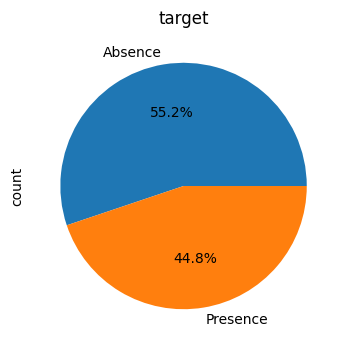

In [5]:
plt.figure(figsize = (12,4))

df_tr['Heart Disease'].value_counts().plot(kind = 'pie', autopct = '%1.1f%%')
plt.title('target')

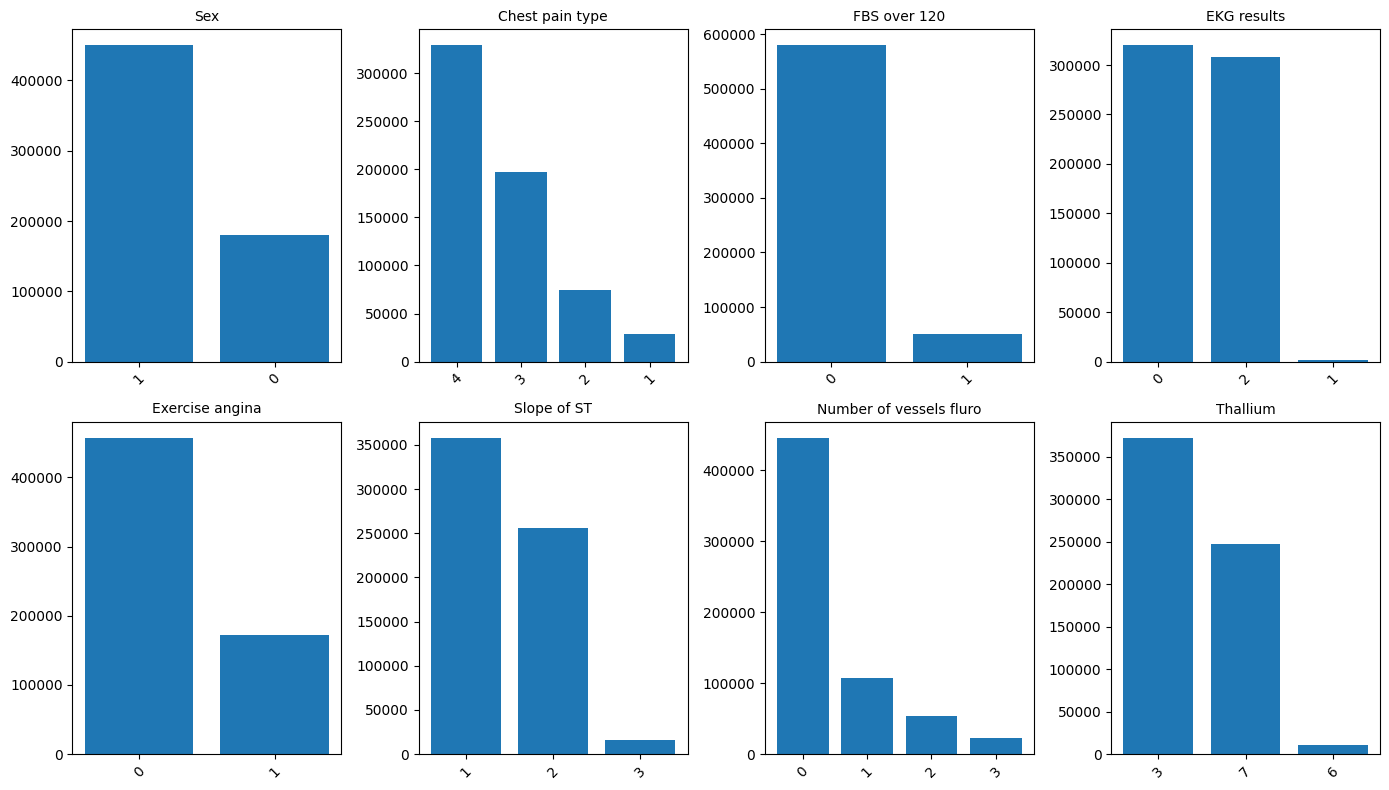

In [47]:
fig, axes = plt.subplots(2, 4, figsize=(14, 8))
axes = axes.flatten()

for i, col in enumerate(cat_cols):
    if i < len(axes):
        value_counts = df_tr[col].value_counts()
        
        bars = axes[i].bar(value_counts.index.astype(str), value_counts.values)
        axes[i].set_title(col, fontsize=10)
        axes[i].set_xlabel('')
        axes[i].tick_params(axis='x', rotation=45)
    

for i in range(len(cat_cols), len(axes)):
    axes[i].axis('off')
    
plt.tight_layout()

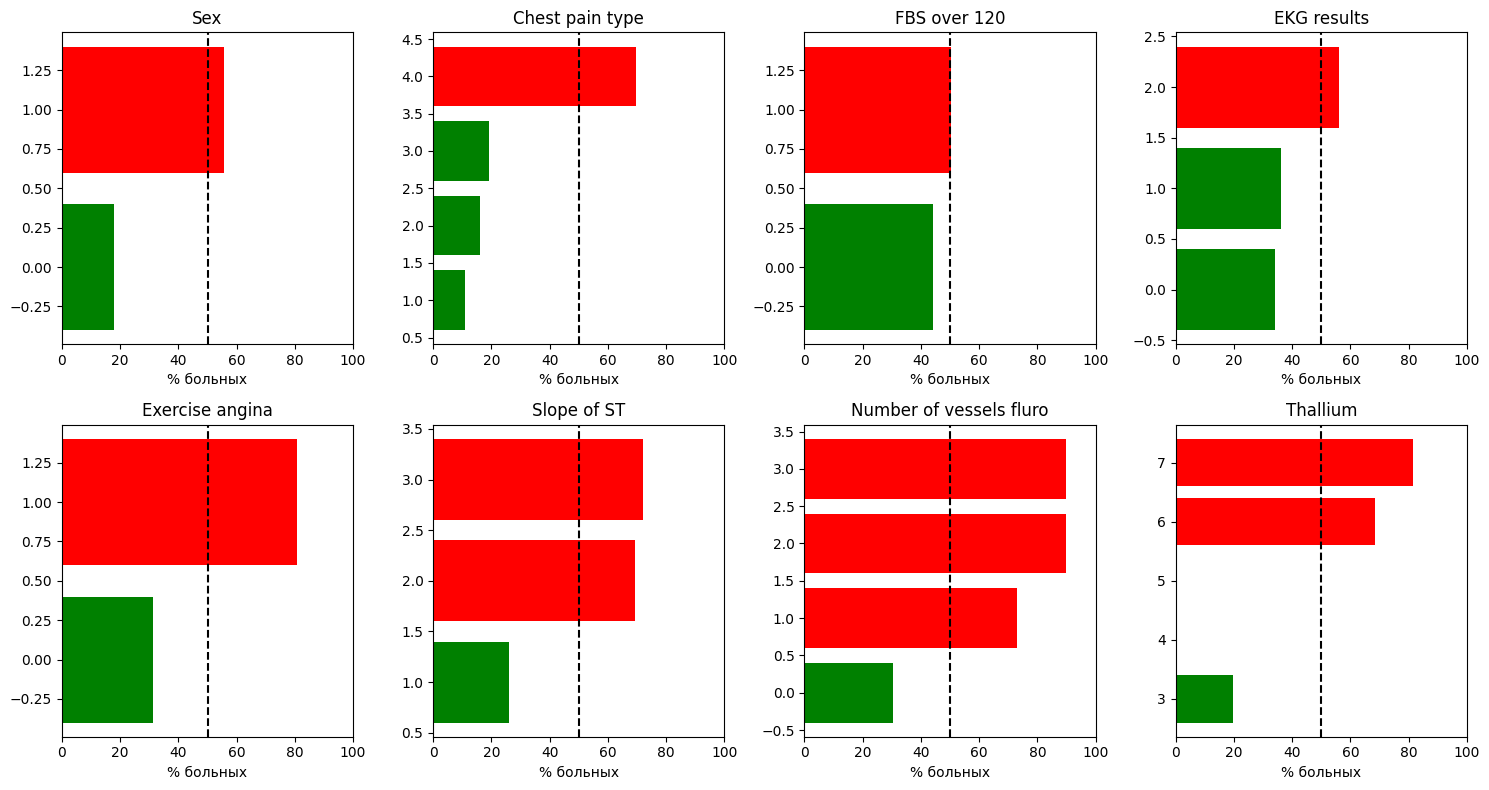

In [36]:
fig, axes = plt.subplots(2, 4, figsize=(15, 8))
axes = axes.flatten()

for i, col in enumerate(cat_cols):
    if i >= len(axes):
        break
        
    result = df_tr.groupby(col)['Heart Disease'].apply(
        lambda x: (x == 'Presence').mean() * 100
    ).round(1)
    
    colors = ['red' if v > 50 else 'green' for v in result.values]
    axes[i].barh(result.index, result.values, color=colors)
    axes[i].axvline(x=50, color='black', linestyle='--')
    axes[i].set_title(col)
    axes[i].set_xlabel('% больных')
    axes[i].set_xlim(0, 100)
    
  
for i in range(len(cat_cols), len(axes)):
    axes[i].axis('off')

plt.tight_layout()


классы, в высокой зоне риска(>=50%) обозначены красным цветом 

чисоловые признаки:

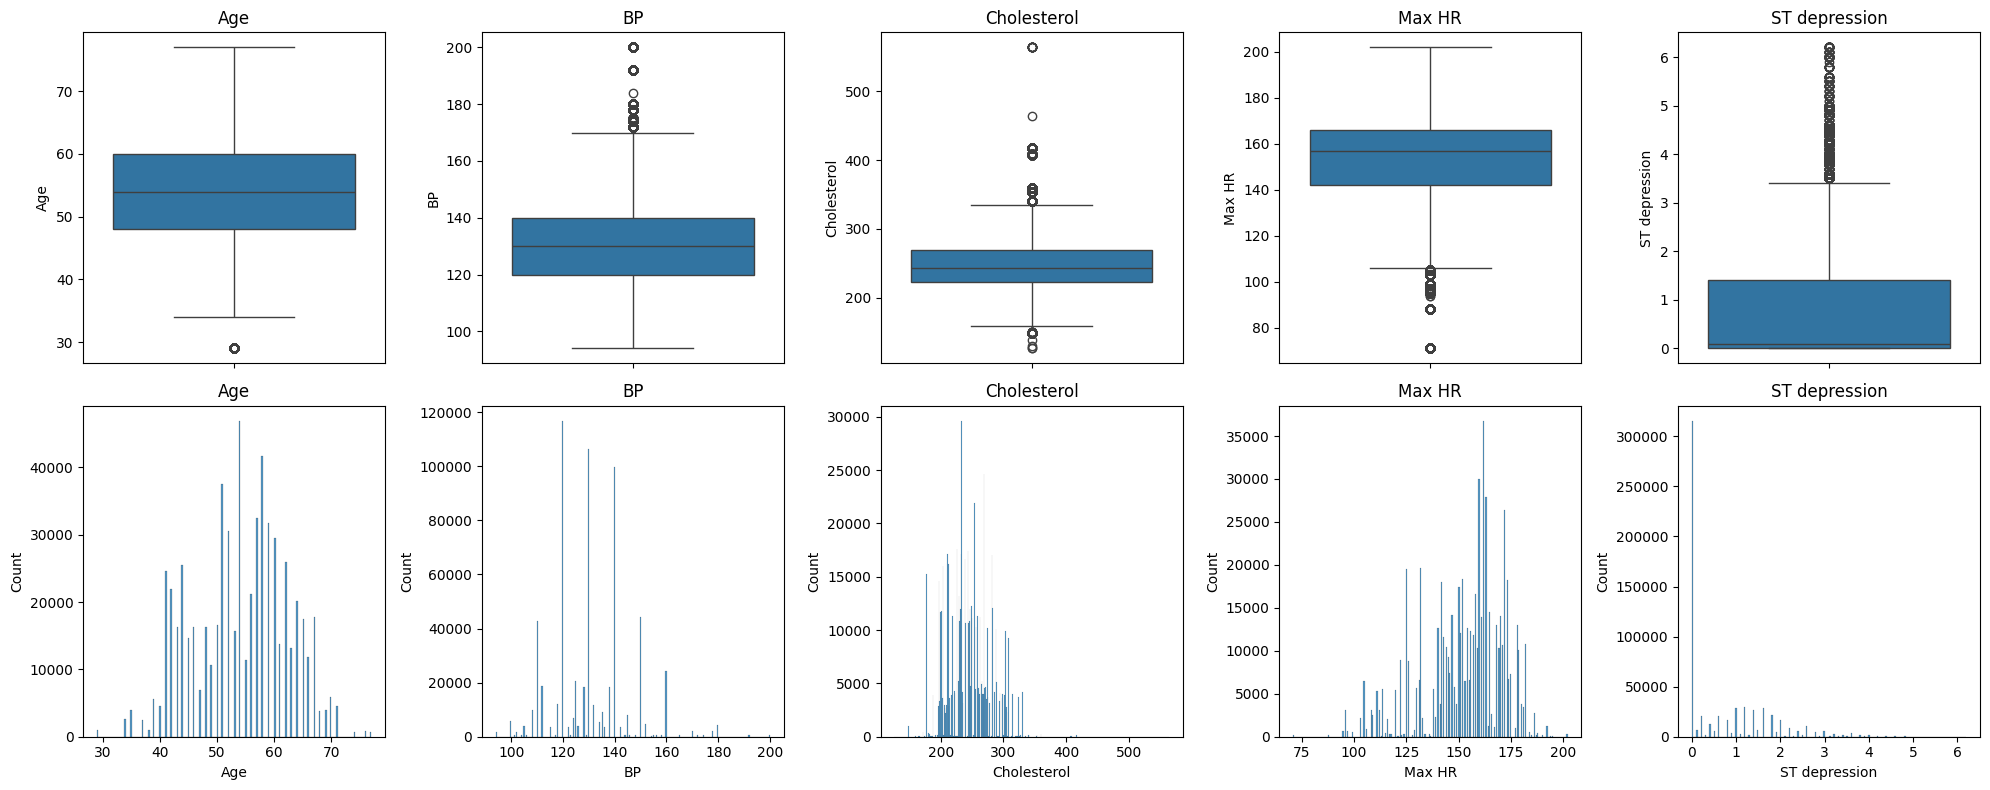

In [59]:
fig, axes = plt.subplots(2, 5, figsize=(20, 8))  

for i, col in enumerate(num_cols):
    #выборсы
    sns.boxplot(y=df_tr[col], ax=axes[0, i])
    axes[0, i].set_title(col)
    
    #распределение
    sns.histplot(df_tr[col], ax=axes[1, i])
    axes[1, i].set_title(col)

plt.tight_layout()
plt.show()

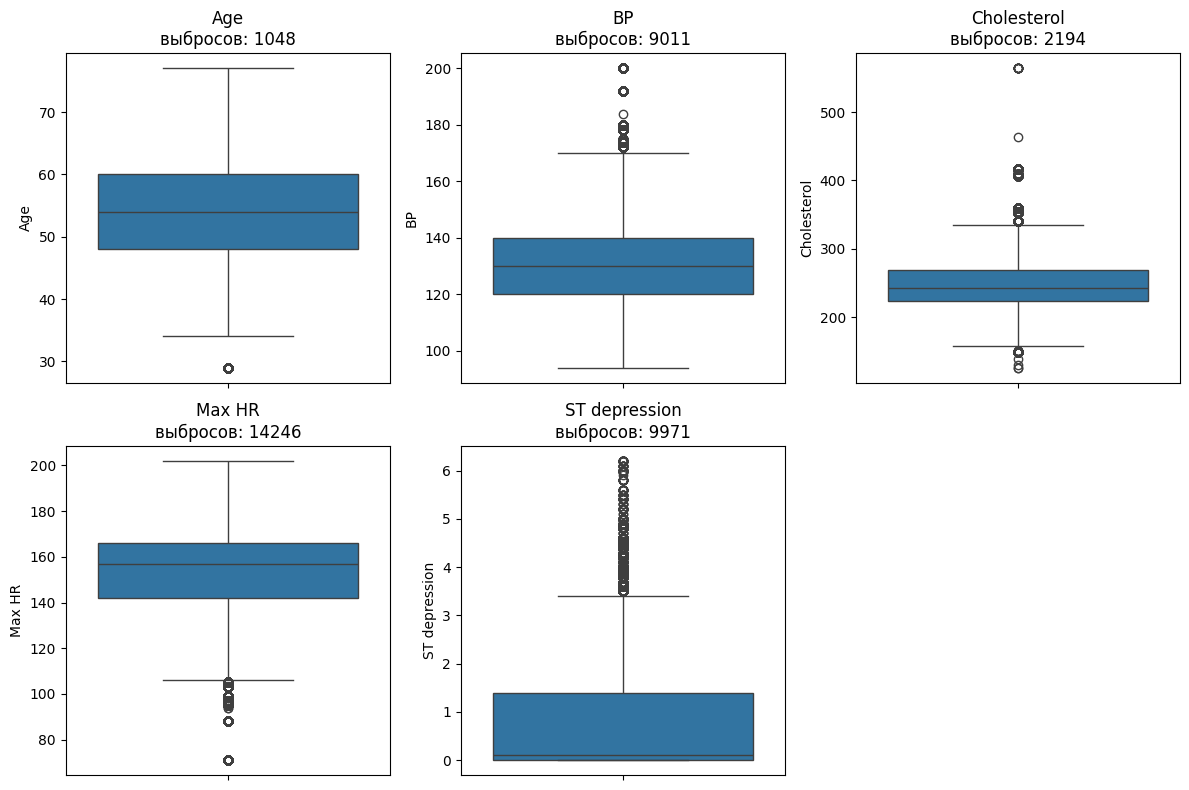

In [63]:
fig, axes = plt.subplots(2, 3, figsize=(12, 8))  
axes_flat = axes.flatten()

for i, col in enumerate(num_cols):
    
    sns.boxplot(y=df_tr[col], ax=axes_flat[i])
    
    Q1 = df_tr[col].quantile(0.25)
    Q3 = df_tr[col].quantile(0.75)
    IQR = Q3 - Q1
    outliers = df_tr[(df_tr[col] < Q1 - 1.5 * IQR) | (df_tr[col] > Q3 + 1.5 * IQR)]
    
    axes_flat[i].set_title(f'{col}\nвыбросов: {len(outliers)}')
    

axes_flat[5].set_visible(False)

plt.tight_layout()

в целом данные распределены расвномерно(за исключением ST depression), кол-во выбросов не критично

распределение ST depression неравномерно, но корректно с медицинской точки зрения(0 без паталогий, 0-1 подозрение, 2+ паталогия)

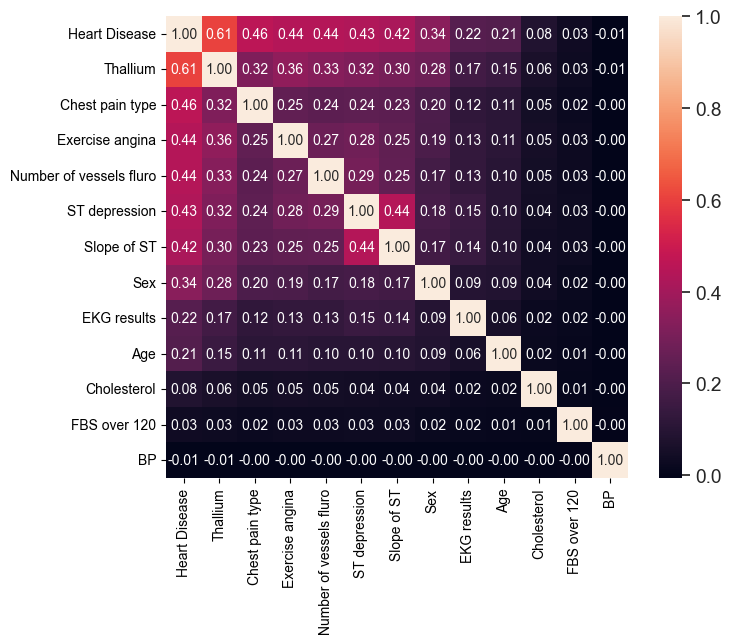

In [5]:
df_tr['Heart Disease'] = df_tr['Heart Disease'].map({'Absence' : 0, 'Presence': 1})
corrmat = df_tr.corr()
f, ax = plt.subplots(figsize=(8, 6))

k = 13
cols = corrmat.nlargest(k, 'Heart Disease')['Heart Disease'].index
cm = np.corrcoef(df_tr[cols].values.T)
sns.set(font_scale=1.25)
hm = sns.heatmap(cm, cbar=True, annot=True, square=True, fmt='.2f', annot_kws={'size': 10}, yticklabels=cols.values, xticklabels=cols.values)

сильная корелляция с таргетом представлена сверху вниз(чем выше признак, тем сильнее корелляция)
корлляция признаков между собой умеренная или низкая

подготовка данных

In [7]:
from sklearn.preprocessing import StandardScaler, OneHotEncoder
from sklearn.compose import ColumnTransformer
import pandas as pd

y = df_tr['Heart Disease']
df_tr.drop(columns=['Heart Disease'], inplace=True)

cols_to_ohenc = ['Chest pain type', 'EKG results']  
cols_to_scale = [col for col in df_tr.columns if col not in cols_to_ohenc]  

preprocessor = ColumnTransformer(
    transformers=[
        ('num', StandardScaler(), cols_to_scale),          
        ('cat', OneHotEncoder(drop='first', sparse_output=False), cols_to_ohenc)  
    ])

In [9]:
df_test = pd.read_csv('../data/test.csv')
df_test.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 270000 entries, 0 to 269999
Data columns (total 14 columns):
 #   Column                   Non-Null Count   Dtype  
---  ------                   --------------   -----  
 0   id                       270000 non-null  int64  
 1   Age                      270000 non-null  int64  
 2   Sex                      270000 non-null  int64  
 3   Chest pain type          270000 non-null  int64  
 4   BP                       270000 non-null  int64  
 5   Cholesterol              270000 non-null  int64  
 6   FBS over 120             270000 non-null  int64  
 7   EKG results              270000 non-null  int64  
 8   Max HR                   270000 non-null  int64  
 9   Exercise angina          270000 non-null  int64  
 10  ST depression            270000 non-null  float64
 11  Slope of ST              270000 non-null  int64  
 12  Number of vessels fluro  270000 non-null  int64  
 13  Thallium                 270000 non-null  int64  
dtypes: f

In [10]:
X_tr = preprocessor.fit_transform(df_tr)  
X_test = preprocessor.transform(df_test)

X_tr = pd.DataFrame(X_tr, index=df_tr.index)
X_test = pd.DataFrame(X_test, index=df_test.index)

In [11]:
X_tr.to_csv('../data/X_tr.csv', index = False)
X_test.to_csv('../data/X_test.csv', index = False)
y.to_csv('../data/y.csv', index = False)